In [1]:
import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
fg.utils.set_mpl_style('ouranos')
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
cat = xs.DataCatalog(CONFIG['extraction']['simulation']['search_data_catalogs']['data_catalogs'][0])

In [3]:
ds_raw=cat.search(
    processing_level= 'raw',
    experiment= 'historical',
    source= 'CRCM5-SN',
    driving_model= 'MPI-ESM1-2-LR',
    driving_member= 'r1i1p1f1',
    variable='pr',
    member= 'r1').to_dataset()
# to make it work with figanos
ds_raw=ds_raw.rename({'crs':'rotated_pole'})
ds_raw

HDF5-DIAG: Error detected in HDF5 (1.14.2) MPI-process 0:
  #000: H5A.c line 679 in H5Aopen_by_name(): unable to synchronously open attribute
    major: Attribute
    minor: Can't open object
  #001: H5A.c line 641 in H5A__open_by_name_api_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #002: H5A.c line 464 in H5A__open_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #003: H5VLcallback.c line 1138 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLcallback.c line 1105 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #005: H5VLnative_attr.c line 169 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Aint.c line 638 in H5A__open_by_name(): un

<xarray.Dataset> Size: 39GB
Dimensions:       (time: 23741, rlat: 628, rlon: 655)
Coordinates:
    rotated_pole  |S1 1B b''
    lat           (rlat, rlon) float64 3MB dask.array<chunksize=(628, 655), meta=np.ndarray>
    lon           (rlat, rlon) float64 3MB dask.array<chunksize=(628, 655), meta=np.ndarray>
  * rlat          (rlat) float64 5kB -33.62 -33.52 -33.41 ... 35.12 35.23 35.34
  * rlon          (rlon) float64 5kB -34.05 -33.94 -33.83 ... 37.67 37.78 37.9
  * time          (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-12...
Data variables:
    pr            (time, rlat, rlon) float32 39GB dask.array<chunksize=(250, 50, 50), meta=np.ndarray>
Attributes: (12/49)
    Conventions:              CF-1.11
    activity_id:              DD
    comment:                  CRCM5 v3331 0.11 deg AMNO11d1 L56 S17-15m MPI-E...
    contact:                  simulations_ouranos@ouranos.ca
    domain:                   North America
    domain_id:                NAM-12
    ...                       ...
    cat:xrfreq:               D
    cat:frequency:            day
    cat:variable:             pr
    cat:domain:               NAM-12
    cat:_data_format_:        nc
    intake_esm_dataset_key:   CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRC...

2025-12-08 13:06:46 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-12-08 13:06:52 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


<GeoAxes: xlabel='longitude in rotated pole grid\n[degrees]', ylabel='latitude in rotated pole grid\n[degrees]'>

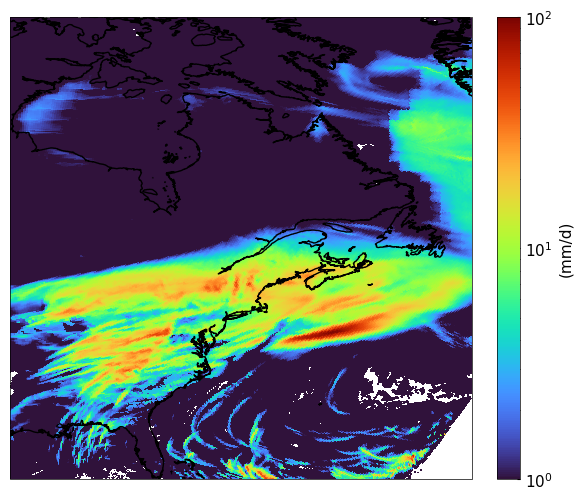

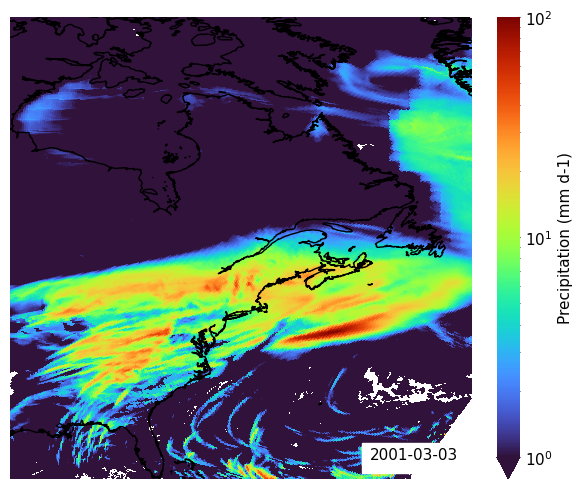

In [4]:
def plot_martin(ds):
    
    # Sélectionner la région
    lon_bnds = [-116, -50]
    lat_bnds = [25, 70]
    
    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=lon_bnds, lat_bnds=lat_bnds)
    data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    

    dt = datetime.fromisoformat(str(data.time.values[0])[:26])
    date_clean = dt.strftime("%Y-%m-%d")

    # Créer une projection cartographique
    projection = ccrs.PlateCarree()

    # Initialiser la figure et les axes
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': projection})

    # Afficher la variable
    p = ax.pcolormesh(data['lon'], data['lat'], data.squeeze(), norm=LogNorm(vmin=1, vmax=100), cmap='turbo')

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    # Ajouter les lignes de côtes
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    plt.colorbar(p,orientation="vertical", label="(mm/d)", fraction=0.046, pad=0.04)
    return ax


def fgplot_martin(ds):

    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=[-116, -50], lat_bnds=[25, 70])
    with xr.set_options(keep_attrs=True):
        data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    # fix xclim bug
    #data.attrs['long_name']= 'Precipitation'

    ax=fg.gridmap(data,
                  #ax=ax,
                  fig_kw=dict(figsize=(8, 6)),
                  plot_kw=dict(norm=LogNorm(vmin=1, vmax=100), cmap='turbo', 
                              cbar_kwargs=dict(orientation="vertical", fraction=0.046, pad=0.04)),
                  features=dict(coastline=dict(scale='10m', color='black', linewidth=1)),
                  projection=ccrs.PlateCarree(),
                  show_time=True,
                 )

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    return ax


plot_martin(ds_raw.sel(time='2001-03-03'))
fgplot_martin(ds_raw.sel(time='2001-03-03'))

2025-12-08 07:57:32 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-08 07:58:27 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-08 07:59:42 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


...

2025-12-08 08:04:24 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-08 08:05:39 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


Text(0.5, 1.0, 'poly4 ')

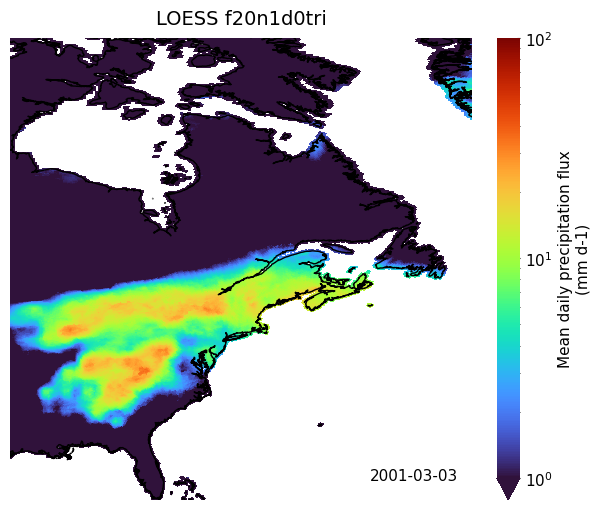

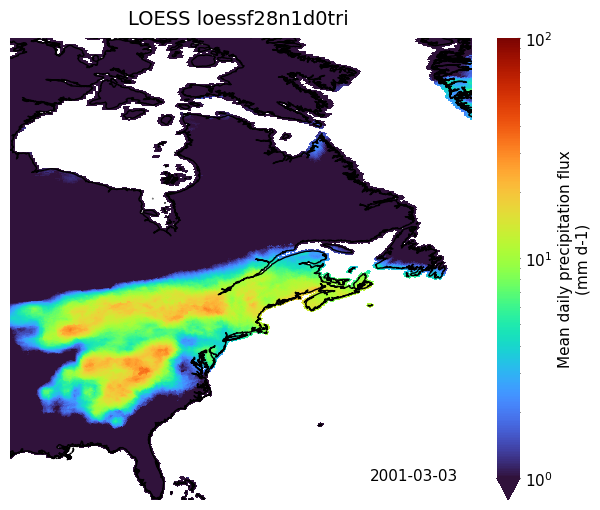

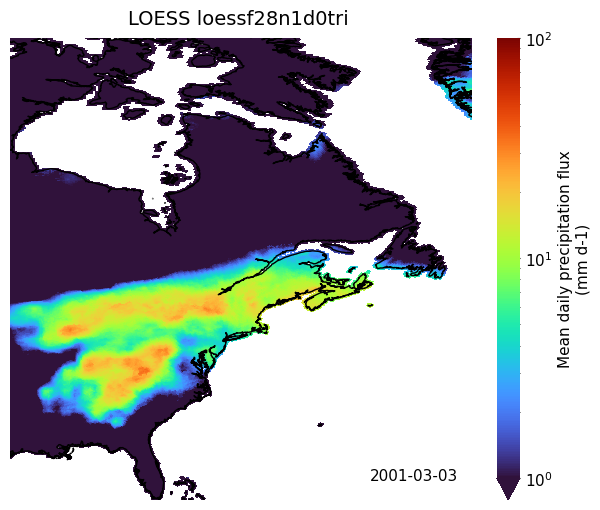

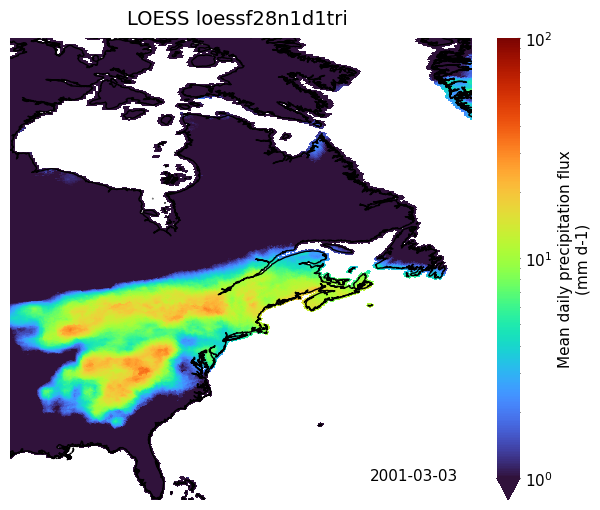

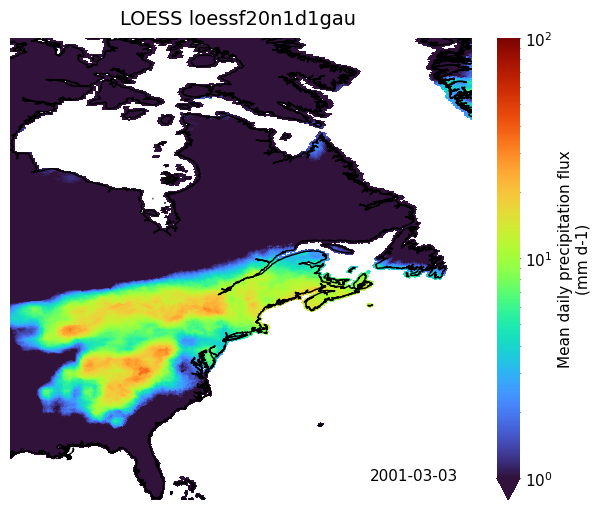

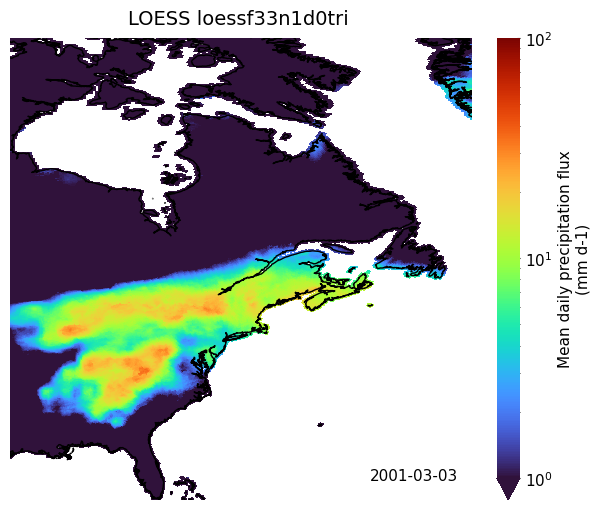

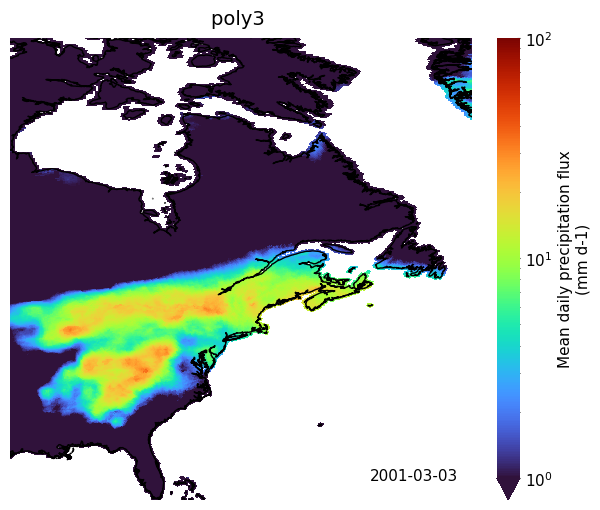

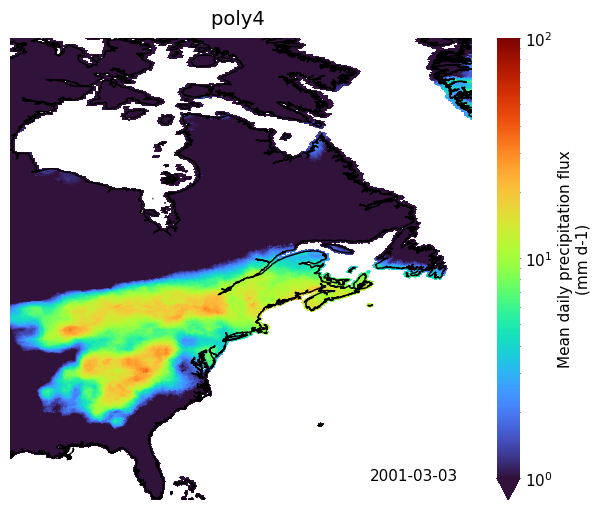

In [5]:
ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS f20n1d0tri")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/loessf20n1d1tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d1tri ")


ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/loessf28n1d0tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d0tri ")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/loessf28n1d1tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d1tri ")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/loessf20n1d1gau/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf20n1d1gau ")


ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/loessf33n1d0tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf33n1d0tri ")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/poly3/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("poly3 ")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/poly4/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("poly4 ")

2025-12-08 08:07:04 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-08 08:08:07 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


Text(0.5, 1.0, 'polyDetrend4 ')

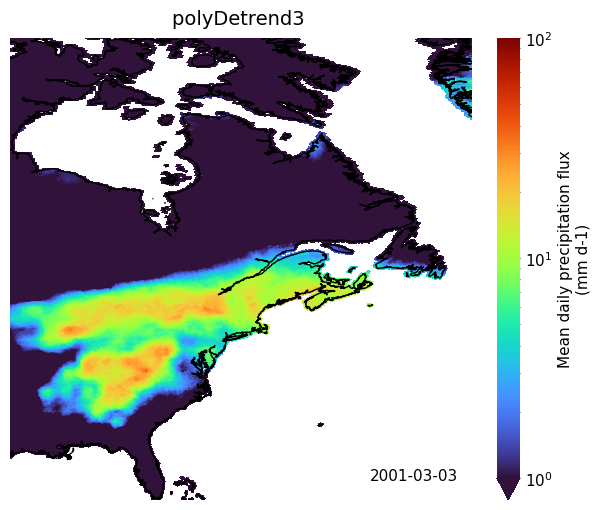

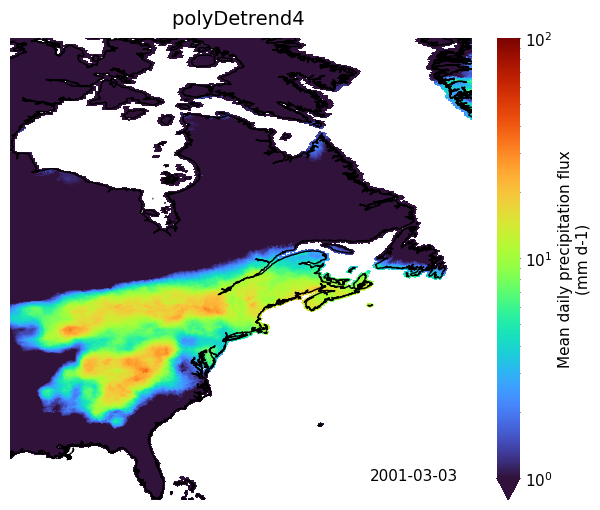

In [6]:
ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/polyDetrend3/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("polyDetrend3 ")

ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/polyDetrend4/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("polyDetrend4 ")

In [7]:
ds_adj

<xarray.Dataset> Size: 103GB
Dimensions:       (time: 55115, rlat: 665, rlon: 700)
Coordinates:
    lat           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    lon           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
  * rlat          (rlat) float32 3kB -33.93 -33.84 -33.75 ... 25.65 25.74 25.83
  * rlon          (rlon) float32 3kB -34.95 -34.86 -34.77 ... 27.78 27.87 27.96
    rotated_pole  |S1 1B ...
  * time          (time) object 441kB 1950-01-01 00:00:00 ... 2100-12-31 00:0...
Data variables:
    pr            (time, rlat, rlon) float32 103GB dask.array<chunksize=(1460, 50, 50), meta=np.ndarray>
Attributes: (12/25)
    Notes:                        Regridded on the grid of CaSR v3.1, then bi...
    avertissement:                Ouranos ne donne aucune garantie, expresse ...
    cat:_data_format_:            zarr
    cat:activity:                 CORDEX
    cat:bias_adjust_institution:  Ouranos
    cat:bias_adjust_project:      ESPO6
    ...                           ...
    disclaimer:                   Ouranos make no warranty, either express or...
    history:                      [2025-12-07 22:36:16] regridded with argume...
    license:                      Creative Commons Attribution 4.0 Internatio...
    organisation:                 Groupe scénarios et services climatiques, C...
    organization:                 Scenarios and Climate Services Group, Ouran...
    version:                      v20

In [9]:
ds_old

<xarray.Dataset> Size: 374GB
Dimensions:       (time: 55115, rlat: 800, rlon: 706)
Coordinates:
    lat           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    lon           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
  * rlat          (rlat) float32 3kB -46.17 -46.08 -45.99 ... 25.56 25.65 25.74
  * rlon          (rlon) float32 3kB 324.6 324.7 324.8 ... 387.9 388.0 388.1
    rotated_pole  float32 4B ...
  * time          (time) object 441kB 1950-01-01 00:00:00 ... 2100-12-31 00:0...
Data variables:
    pr            (time, rlat, rlon) float32 125GB dask.array<chunksize=(1460, 50, 50), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 125GB dask.array<chunksize=(1460, 50, 50), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 125GB dask.array<chunksize=(1460, 50, 50), meta=np.ndarray>
Attributes: (12/59)
    Conventions:                  CF-1.11
    NCO:                          netCDF Operators version 5.1.8 (Homepage = ...
    Notes:                        Regridded on the grid of RDRS v2.1, then bi...
    activity_id:                  DD
    cat:_data_format_:            zarr
    cat:activity:                 CORDEX
    ...                           ...
    source_type:                  ARCM
    title:                        CRMC5 output, model ran by Ouranos, prepare...
    tracking_id:                  hdl:21.14100/9eaab31f-7c1d-492a-a1aa-a02579...
    variable_id:                  tasmax
    version:                      1.0.0
    version_realization:          v1-r1

2025-12-08 08:09:07 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


Text(0.5, 1.0, 'old poly3 ')

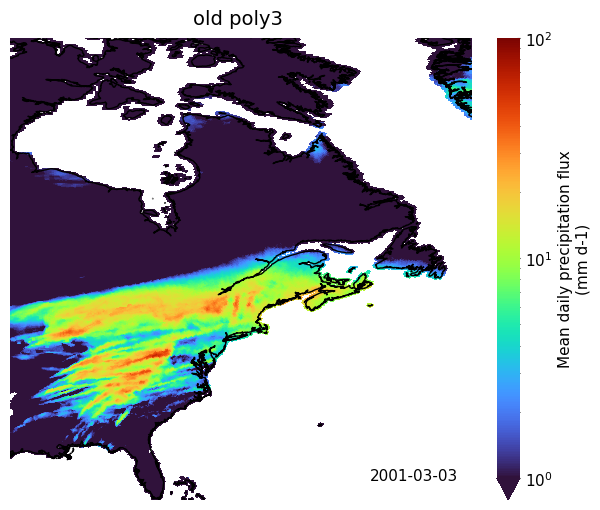

In [8]:
ds_old=xr.open_zarr('/scratch/julavoie/tmp/day_CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-rdrs_1950-2100.zarr')
ax=fgplot_martin(ds_old.sel(time='2001-03-03'))
ax.set_title("old poly3 ")

In [ ]:
ds_adj= xr.open_zarr(f"{CONFIG['paths']['final']}/dec2025/loessf28n1d1tri                     /staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d1tri ")

In [1]:
# test

import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
fg.utils.set_mpl_style('ouranos')

def fgplot_martin(ds):

    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=[-116, -50], lat_bnds=[25, 70])
    with xr.set_options(keep_attrs=True):
        data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    # fix xclim bug
    #data.attrs['long_name']= 'Precipitation'

    ax=fg.gridmap(data,
                  #ax=ax,
                  fig_kw=dict(figsize=(8, 6)),
                  plot_kw=dict(norm=LogNorm(vmin=1, vmax=100), cmap='turbo', 
                              cbar_kwargs=dict(orientation="vertical", fraction=0.046, pad=0.04)),
                  features=dict(coastline=dict(scale='10m', color='black', linewidth=1)),
                  projection=ccrs.PlateCarree(),
                  show_time=True,
                 )

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    return ax




/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


<GeoAxes: xlabel='longitude in rotated pole grid\n[degrees]', ylabel='latitude in rotated pole grid\n[degrees]'>

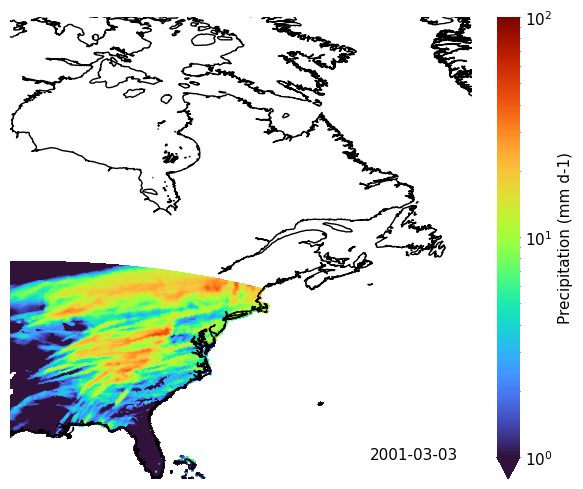

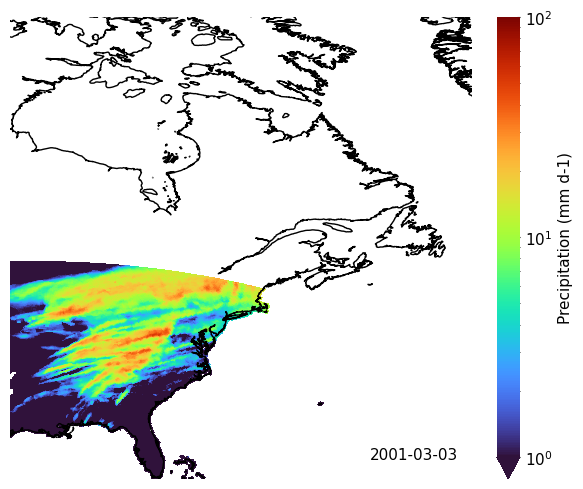

In [2]:
ds_reg=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+NAM-C3+southC3+regchunked.zarr')
#ds_reg=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+southC3+southC3+regchunked.zarr')
#ds_train=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+southC3+southC3+pr+training.zarr')
ds_ref= xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/reference/split_regions/NAM-C3_southC3_noleap.zarr.zip')
ds_reg_plot=xs.utils.unstack_fill_nan(ds_reg, coords='/project/ctb-frigon/julavoie/ESPO/coords/coords_{domain}_{shape}.nc')
fgplot_martin(ds_reg_plot.sel(time='2001-03-03'))




ds_hist = ds_reg
    
# load ref ds
# choose right calendar
simcal = xc.core.calendar.get_calendar(ds_hist)
refcal = xs.utils.minimum_calendar(simcal, 'noleap')

# snakemake can't have 360_day as a keyword..
input_cal = 'noleap' if refcal == 'noleap' else  'day360' if refcal == '360_day' else 'unknown'

# training
ds_tr = xs.train(
    dref=ds_ref,
    dhist=ds_hist,
    var=['pr'],
    method= 'DetrendedQuantileMapping',
    period=['1991','2020'],
    group= dict(
        group= 'time.dayofyear',
        window= 31),
    jitter_under=dict( 
       thresh= '0.01 mm d-1'),
    xsdba_train_args=dict(
        kind= "*",
        nquantiles= 50,
        adapt_freq_thresh= "1.1574e-05 kg m^-2 s^-1"  # xsdba cant convert mm/day automatically

    ),
    )

ds_tr = ds_tr.chunk({'loc':600})
for v in ['lat','lon']:
    del ds_tr[v].encoding['chunks']

xs.save_to_zarr(ds_tr, '/scratch/julavoie/espo-workdir/ds_tr.zarr')

ds_scen = xs.adjust(
    dsim=ds_reg,
    dtrain=ds_tr,
    periods=['1950','2100'],
    xsdba_adjust_args=dict(detrend={'LoessDetrend': {'f':0.2,'niter':1,'d':0,'weights':'tricube'}},
                           interp='nearest',
                           extrapolation='constant'
                          )
    )

ds_scen=xs.utils.unstack_fill_nan(ds_scen, coords='/project/ctb-frigon/julavoie/ESPO/coords/coords_{domain}_{shape}.nc')
fgplot_martin(ds_scen.sel(time='2001-03-03'))

In [6]:
ds_reg.rlat.attrs['original_shape'],ds_scen.rlat.attrs['original_shape'],ds_reg.attrs['cat:domain'],ds_scen.attrs['cat:domain']

('244x700', '244x700', 'southC3', 'southC3')

In [8]:
ds_train

<xarray.Dataset> Size: 12GB
Dimensions:       (loc: 80205, dayofyear: 365, quantiles: 50)
Coordinates:
    crs           |S1 1B ...
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
    lat           (loc) float32 321kB dask.array<chunksize=(600,), meta=np.ndarray>
  * loc           (loc) int64 642kB 0 1 2 3 4 ... 80200 80201 80202 80203 80204
    lon           (loc) float32 321kB dask.array<chunksize=(600,), meta=np.ndarray>
  * quantiles     (quantiles) float32 200B 0.01 0.03 0.05 ... 0.95 0.97 0.99
    rlat          (loc) float32 321kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 321kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  |S1 1B ...
Data variables:
    P0_hist       (loc, dayofyear) float32 117MB dask.array<chunksize=(600, 365), meta=np.ndarray>
    P0_ref        (loc, dayofyear) float32 117MB dask.array<chunksize=(600, 365), meta=np.ndarray>
    af            (loc, dayofyear, quantiles) float32 6GB dask.array<chunksize=(600, 365, 50), meta=np.ndarray>
    hist_q        (loc, dayofyear, quantiles) float32 6GB dask.array<chunksize=(600, 365, 50), meta=np.ndarray>
    pth           (loc, dayofyear) float32 117MB dask.array<chunksize=(600, 365), meta=np.ndarray>
    scaling       (loc, dayofyear) float32 117MB dask.array<chunksize=(600, 365), meta=np.ndarray>
Attributes:
    _xsdba_adjustment:     {"py/object": "xsdba.adjustment.DetrendedQuantileM...
    adj_params:            DetrendedQuantileMapping(group=Grouper(name='time....
    cat:domain:            northC3
    cat:id:                CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-...
    cat:processing_level:  training_pr
    cat:xrfreq:            D
    train_params:          {'var': ['pr'], 'maximal_calendar': 'noleap', 'xsd...

In [7]:
ds_reg

<xarray.Dataset> Size: 76GB
Dimensions:       (time: 55152, loc: 86609)
Coordinates:
    crs           |S1 1B b''
    lat           (loc) float32 346kB 22.74 22.76 22.78 ... 43.52 43.49 43.46
  * loc           (loc) int64 693kB 0 1 2 3 4 ... 86604 86605 86606 86607 86608
    lon           (loc) float32 346kB -106.2 -106.1 -106.0 ... -70.22 -70.11
    rlat          (loc) float32 346kB -33.93 -33.93 -33.93 ... -12.06 -12.06
    rlon          (loc) float32 346kB -15.33 -15.24 -15.15 ... 16.17 16.26 16.35
    rotated_pole  |S1 1B b''
  * time          (time) datetime64[ns] 441kB 1950-01-01 ... 2100-12-31
Data variables:
    dtr           (time, loc) float32 19GB dask.array<chunksize=(55152, 600), meta=np.ndarray>
    pr            (time, loc) float32 19GB dask.array<chunksize=(55152, 600), meta=np.ndarray>
    tasmax        (time, loc) float32 19GB dask.array<chunksize=(55152, 600), meta=np.ndarray>
    tasmin        (time, loc) float32 19GB dask.array<chunksize=(55152, 600), meta=np.ndarray>
Attributes: (12/56)
    Conventions:              CF-1.11
    NCO:                      netCDF Operators version 5.1.8 (Homepage = http...
    activity_id:              DD
    cat:_data_format_:        nc
    cat:activity:             CORDEX
    cat:date_end:             1950-12-31 23:00:00
    ...                       ...
    source_name:              CRCM5
    source_type:              ARCM
    title:                    CRMC5 output, model ran by Ouranos, prepared fo...
    tracking_id:              hdl:21.14100/9eaab31f-7c1d-492a-a1aa-a02579ae6c8c
    variable_id:              tasmax
    version_realization:      v1-r1

In [3]:
ds_scen

<xarray.Dataset> Size: 18GB
Dimensions:       (loc: 80205, time: 55115)
Coordinates:
  * loc           (loc) int64 642kB 0 1 2 3 4 ... 80200 80201 80202 80203 80204
  * time          (time) object 441kB 1950-01-01 00:00:00 ... 2100-12-31 00:0...
    crs           |S1 1B b''
    rotated_pole  |S1 1B b''
    lat           (loc) float32 321kB nan nan nan nan nan ... nan nan nan nan
    lon           (loc) float32 321kB nan nan nan nan nan ... nan nan nan nan
    rlat          (loc) float32 321kB nan nan nan nan nan ... nan nan nan nan
    rlon          (loc) float32 321kB nan nan nan nan nan ... nan nan nan nan
Data variables:
    pr            (loc, time) float32 18GB dask.array<chunksize=(597, 55115), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                  CF-1.11
    NCO:                          netCDF Operators version 5.1.8 (Homepage = ...
    activity_id:                  DD
    cat:_data_format_:            nc
    cat:activity:                 CORDEX
    cat:date_end:                 1950-12-31 23:00:00
    ...                           ...
    title:                        CRMC5 output, model ran by Ouranos, prepare...
    tracking_id:                  hdl:21.14100/9eaab31f-7c1d-492a-a1aa-a02579...
    variable_id:                  tasmax
    version_realization:          v1-r1
    cat:bias_adjust_institution:  unknown
    cat:bias_adjust_project:      unknown